# Boundary-Driven XXZ Steady States in the Pauli Basis

This notebook computes nonequilibrium steady-state magnetization profiles for a boundary-driven spin-1/2 XXZ chain using TEBD in the Pauli basis.

The setup follows the standard boundary-driving picture used in the open XXZ literature: opposite spin-polarizing baths act on the left and right edges through local Lindblad jump operators. In this notebook, the density matrix is represented as a Pauli-basis `MPS`, and each local TEBD gate is built from a local Lindbladian term.

What this example shows:

- how to build a boundary-driven XXZ Lindbladian from local jump operators
- how to evolve a density matrix to a near-steady state with Pauli-basis TEBD
- how the final magnetization profile changes across the easy-plane, isotropic, and easy-axis regimes

The practical choices here are tuned for a qualitative example rather than precision transport extraction. After testing a few options, the best compromise was:

- stronger boundary bias `mu = 1` to make the profile visible sooner
- a shorter chain than the earlier draft
- an initial density profile already interpolating between the bath polarizations, which reduces the transient toward the steady state

References used for the setup and interpretation:

- T. Prosen, [Exact nonequilibrium steady state of a strongly driven open XXZ chain](https://arxiv.org/abs/1106.2978)
- D. Karevski, V. Popkov, G. M. Schütz, [Exact matrix product solution for the boundary-driven Lindblad XXZ-chain](https://arxiv.org/abs/1211.7010)


In [1]:
using Random
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
using MPSToolkit

default(size=(980, 700), linewidth=2, markersize=4, legend=:best)


## Boundary driving model

The Hamiltonian is the open XXZ chain

```math
H = \sum_{j=1}^{L-1} \left(S^x_j S^x_{j+1} + S^y_j S^y_{j+1} + \Delta S^z_j S^z_{j+1}\right).
```

The boundary baths are encoded by local jump operators on the first and last site:

```math
L_1 = \sqrt{\Gamma (1 + \mu)/2}\,\sigma_1^+, \qquad
L_2 = \sqrt{\Gamma (1 - \mu)/2}\,\sigma_1^-,
```

```math
L_3 = \sqrt{\Gamma (1 - \mu)/2}\,\sigma_L^+, \qquad
L_4 = \sqrt{\Gamma (1 + \mu)/2}\,\sigma_L^-.
```

This drives the left edge toward positive magnetization and the right edge toward negative magnetization.

The notebook compares three anisotropies:

- `Δ = 0.5` in the easy-plane regime
- `Δ = 1.0` at the isotropic superdiffusive point
- `Δ = 1.5` in the easy-axis regime


In [2]:
function sigma_plus()
    return ComplexF64[0 1; 0 0]
end

function sigma_minus()
    return ComplexF64[0 0; 1 0]
end

function boundary_driven_xxz_term(nsites, bond; Delta::Real, Gamma::Real, mu::Real, weight::Real)
    hamiltonian = weight * spinhalf_xyz_bond_hamiltonian(; Jx=1.0, Jy=1.0, Jz=Delta)
    spins = spinhalf_matrices()
    jumps = Matrix{ComplexF64}[]

    if bond == 1
        push!(jumps, sqrt(weight * Gamma * (1 + mu) / 2) * kron(sigma_plus(), spins.I))
        push!(jumps, sqrt(weight * Gamma * (1 - mu) / 2) * kron(sigma_minus(), spins.I))
    end
    if bond == nsites - 1
        push!(jumps, sqrt(weight * Gamma * (1 - mu) / 2) * kron(spins.I, sigma_plus()))
        push!(jumps, sqrt(weight * Gamma * (1 + mu) / 2) * kron(spins.I, sigma_minus()))
    end

    return (; hamiltonian=hamiltonian, jumps=jumps)
end

function linear_profile_density(sites; left_polarization::Real, right_polarization::Real)
    nsites = length(sites)
    tensors = ITensor[]
    for site in 1:nsites
        tensor = ITensor(sites[site])
        polarization = nsites == 1 ? left_polarization : left_polarization + (right_polarization - left_polarization) * (site - 1) / (nsites - 1)
        tensor[sites[site] => 1] = 1 / sqrt(2)
        tensor[sites[site] => 4] = polarization / sqrt(2)
        push!(tensors, tensor)
    end
    return MPS(tensors)
end

function identity_operator_state(sites)
    return pauli_basis_state(sites, fill("I", length(sites)))
end

function local_sz_operators(sites)
    nsites = length(sites)
    return [pauli_basis_state(sites, [site == j ? "Z" : "I" for site in 1:nsites]; coefficient=0.5) for j in 1:nsites]
end

function density_trace(rho_state, identity_state)
    nsites = length(rho_state)
    return real((2.0^(nsites / 2)) * inner(identity_state, rho_state))
end

function magnetization_profile(rho_state, identity_state, sz_ops)
    tr_rho = density_trace(rho_state, identity_state)
    return [real(inner(op, rho_state)) / tr_rho for op in sz_ops]
end

function normalize_density_trace!(rho_state, identity_state)
    trace_value = density_trace(rho_state, identity_state)
    abs(trace_value) > 1e-14 || throw(ArgumentError("density-matrix trace is too small to renormalize"))
    rho_state[1] *= inv(trace_value)
    return rho_state
end

function run_boundary_driven_xxz(; nsites::Integer, Delta::Real, Gamma::Real, mu::Real, dt::Real, max_time::Real, sample_every::Integer, maxdim::Integer, cutoff::Real, steady_tol::Real, min_time::Real, patience::Integer)
    sites = pauli_siteinds(nsites)
    rho = linear_profile_density(sites; left_polarization=mu, right_polarization=-mu)
    identity_state = identity_operator_state(sites)
    sz_ops = local_sz_operators(sites)

    evolution = tebd_strang_evolution(
        nsites,
        dt;
        local_hamiltonian=(bond, weight) -> boundary_driven_xxz_term(nsites, bond; Delta=Delta, Gamma=Gamma, mu=mu, weight=weight),
        map_hamiltonian=(term, step_dt) -> pauli_gate_from_lindbladian(term.hamiltonian, term.jumps, step_dt),
        maxdim=maxdim,
        cutoff=cutoff,
    )

    max_steps = round(Int, max_time / dt)
    measure_steps = Set(collect(0:sample_every:max_steps))
    times = Float64[]
    traces = Float64[]
    residuals = Float64[]
    entropies = Float64[]
    maxlinkdims = Int[]
    profile_history = Vector{Vector{Float64}}()
    last_profile = nothing
    stable_count = 0

    for step in 0:max_steps
        if step in measure_steps
            profile = magnetization_profile(rho, identity_state, sz_ops)
            trace_value = density_trace(rho, identity_state)
            absolute_residual = isnothing(last_profile) ? Inf : maximum(abs.(profile .- last_profile))
            profile_scale = max(maximum(abs.(profile)), 1e-12)
            residual = isfinite(absolute_residual) ? absolute_residual / profile_scale : Inf
            current_time = step * dt

            push!(times, current_time)
            push!(traces, trace_value)
            push!(residuals, residual)
            push!(entropies, bond_entropy(rho, nsites ÷ 2))
            push!(maxlinkdims, maxlinkdim(rho))
            push!(profile_history, copy(profile))

            if current_time >= min_time && isfinite(residual) && residual < steady_tol
                stable_count += 1
            else
                stable_count = 0
            end
            stable_count >= patience && break
            last_profile = profile
        end
        step == max_steps && break
        evolve!(rho, evolution)
        normalize_density_trace!(rho, identity_state)
    end

    return (; times, traces, residuals, entropies, maxlinkdims, profile_history, final_profile=profile_history[end], Delta=Delta)
end


run_boundary_driven_xxz (generic function with 1 method)

## Parameters

Based on the standard strong-driving setup used in the exact-solution literature, the example uses a stronger bias and a seed state closer to the final NESS. That is a better fit for a notebook whose goal is to show visible steady-state profiles without a very long run.

After testing a few parameter sets, the most practical compromise was:

- `nsites = 14`: larger than the smaller demo version, while still staying within notebook territory
- `Gamma = 2.0`: stronger boundary coupling to speed up relaxation
- `mu = 1.0`: maximal boundary polarization, following the strong-driving convention used in exact NESS work
- `dt = 0.05`: TEBD step size
- `max_time = 6.0`: longer evolution than the earlier draft, which helps the profile build up
- `sample_every = 8`: sample every eight TEBD sweeps
- `maxdim = 48`: intentionally modest, since this is a qualitative profile notebook rather than a precision simulation
- `cutoff = 1e-8`: slightly looser compression to keep the longer run practical
- `steady_tol = 1e-2`: relative profile-change threshold
- `min_time = 3.0`, `patience = 3`: require a later and more stable plateau before stopping

This parameter set is meant to separate the three regimes qualitatively. It is not tuned for quantitative current scaling.


In [6]:
Random.seed!(5)

nsites = 14
Gamma = 2.0
mu = 1.0
dt = 0.05
max_time = 20
sample_every = 8
maxdim = 48
cutoff = 1e-8
steady_tol = 1e-2
min_time = 3.0
patience = 60

easy_plane = run_boundary_driven_xxz(
    ;
    nsites=nsites,
    Delta=0.5,
    Gamma=Gamma,
    mu=mu,
    dt=dt,
    max_time=max_time,
    sample_every=sample_every,
    maxdim=maxdim,
    cutoff=cutoff,
    steady_tol=steady_tol,
    min_time=min_time,
    patience=patience,
)

isotropic = run_boundary_driven_xxz(
    ;
    nsites=nsites,
    Delta=1.0,
    Gamma=Gamma,
    mu=mu,
    dt=dt,
    max_time=max_time,
    sample_every=sample_every,
    maxdim=maxdim,
    cutoff=cutoff,
    steady_tol=steady_tol,
    min_time=min_time,
    patience=patience,
)

easy_axis = run_boundary_driven_xxz(
    ;
    nsites=nsites,
    Delta=1.5,
    Gamma=Gamma,
    mu=mu,
    dt=dt,
    max_time=max_time,
    sample_every=sample_every,
    maxdim=maxdim,
    cutoff=cutoff,
    steady_tol=steady_tol,
    min_time=min_time,
    patience=patience,
)

println("Delta = 0.5 final time = ", easy_plane.times[end])
println("Delta = 1.0 final time = ", isotropic.times[end])
println("Delta = 1.5 final time = ", easy_axis.times[end])
println("Delta = 0.5 final relative residual = ", easy_plane.residuals[end])
println("Delta = 1.0 final relative residual = ", isotropic.residuals[end])
println("Delta = 1.5 final relative residual = ", easy_axis.residuals[end])
println("Delta = 0.5 max bond dimension = ", maximum(easy_plane.maxlinkdims))
println("Delta = 1.0 max bond dimension = ", maximum(isotropic.maxlinkdims))
println("Delta = 1.5 max bond dimension = ", maximum(easy_axis.maxlinkdims))


Delta = 0.5 final time = 20.0
Delta = 1.0 final time = 20.0
Delta = 1.5 final time = 20.0
Delta = 0.5 final relative residual = 0.003999436072060247
Delta = 1.0 final relative residual = 0.005923940195587612
Delta = 1.5 final relative residual = 0.004841425303684518
Delta = 0.5 max bond dimension = 48
Delta = 1.0 max bond dimension = 48
Delta = 1.5 max bond dimension = 48


## Steady-state profiles and convergence

The top-left panel is the main result: the magnetization profile after the TEBD run has approached a steady state.

For a fixed chain length, the interpretation is qualitative:

- flatter profile: more ballistic-like transport
- intermediate profile: superdiffusive point
- steeper profile: less efficient transport in the easy-axis regime

The other panels show the convergence diagnostics, so the final profiles are not just snapshots at arbitrary times.


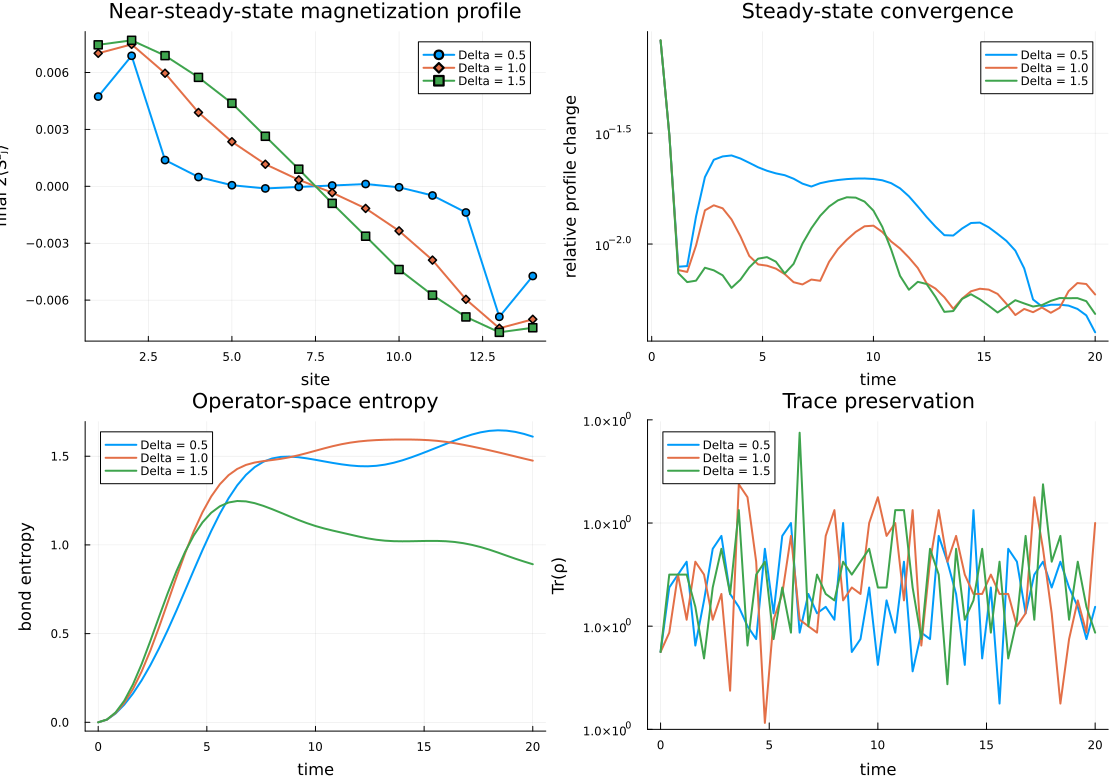

In [7]:
profile_plot = plot(layout=(2, 2), size=(1120, 780))

plot!(
    profile_plot[1],
    1:nsites,
    2 .* easy_plane.final_profile;
    marker=:circle,
    label="Delta = 0.5",
    xlabel="site",
    ylabel="final 2⟨Sᶻⱼ⟩",
    title="Near-steady-state magnetization profile",
)
plot!(
    profile_plot[1],
    1:nsites,
    2 .* isotropic.final_profile;
    marker=:diamond,
    label="Delta = 1.0",
)
plot!(
    profile_plot[1],
    1:nsites,
    2 .* easy_axis.final_profile;
    marker=:square,
    label="Delta = 1.5",
)

plot!(
    profile_plot[2],
    easy_plane.times[2:end],
    easy_plane.residuals[2:end];
    label="Delta = 0.5",
    xlabel="time",
    ylabel="relative profile change",
    yscale=:log10,
    title="Steady-state convergence",
)
plot!(
    profile_plot[2],
    isotropic.times[2:end],
    isotropic.residuals[2:end];
    label="Delta = 1.0",
)
plot!(
    profile_plot[2],
    easy_axis.times[2:end],
    easy_axis.residuals[2:end];
    label="Delta = 1.5",
)

plot!(
    profile_plot[3],
    easy_plane.times,
    easy_plane.entropies;
    label="Delta = 0.5",
    xlabel="time",
    ylabel="bond entropy",
    title="Operator-space entropy",
)
plot!(
    profile_plot[3],
    isotropic.times,
    isotropic.entropies;
    label="Delta = 1.0",
)
plot!(
    profile_plot[3],
    easy_axis.times,
    easy_axis.entropies;
    label="Delta = 1.5",
)

plot!(
    profile_plot[4],
    easy_plane.times,
    easy_plane.traces;
    label="Delta = 0.5",
    xlabel="time",
    ylabel="Tr(ρ)",
    title="Trace preservation",
)
plot!(
    profile_plot[4],
    isotropic.times,
    isotropic.traces;
    label="Delta = 1.0",
)
plot!(
    profile_plot[4],
    easy_axis.times,
    easy_axis.traces;
    label="Delta = 1.5",
)

display(profile_plot)


## What to look for

This notebook is meant to be a boundary-driven transport example, not a scaling analysis.

For transport classification in the thermodynamic limit you would normally also study:

- several system sizes `L`
- current scaling with `L`
- weak-driving behavior close to linear response

For a notebook demo, though, strong driving is helpful. The exact-solution literature often uses maximal or near-maximal boundary polarization, and that is a good fit here because it makes the profiles visible faster.

So the intended qualitative takeaways are:

- the `Δ = 0.5` profile should stay the flattest
- the `Δ = 1.0` profile should sit between the other two
- the `Δ = 1.5` profile should show the strongest gradient
- the relative residual curves should flatten as the runs approach their near-steady-state profiles

That is the qualitative three-regime comparison this example is designed to show.
